# 04 — VQ-VAE

Vector Quantized Variational Autoencoder — discrete latent space for image generation.

**Architecture:** Encoder → Vector Quantizer (codebook) → Decoder

**Generation limitation:** Random codebook sampling without PixelCNN prior.
This means generated images may lack global coherence since we're sampling codebook vectors independently.
A proper implementation would train a PixelCNN/Transformer on the codebook indices.

**Reference:** kamenbliznashki/generative_models

## Setup

In [1]:
!pip install torchxrayvision -q
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from scipy import linalg

import torchxrayvision as xrv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 65.7 MB/s eta 0:00:00
Device: cuda


In [2]:
# hyperparameters
IMG_SIZE = 64
CHANNELS = 1
HIDDEN_DIM = 128
EMBED_DIM = 64  # codebook embedding dimension
NUM_EMBEDDINGS = 512  # codebook size
BETA = 0.25  # commitment loss weight
BATCH_SIZE = 32
LR = 1e-3
N_EPOCHS = 50
N_GENERATE = 100

In [3]:
# paths
# DATA_DIR = Path("../data")  # for local use
DATA_DIR = Path("/kaggle/input/datasets/lakshyarathi/lungpp/data")
REAL_DIR = DATA_DIR / "pneumonia"

OUTPUT_DIR = Path("outputs/04_vqvae")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

## Dataset Loading

In [4]:
class XrayDataset(Dataset):
    def __init__(self, folder: Path, transform=None):
        self.paths = sorted([
            p for p in folder.iterdir()
            if p.suffix.lower() in {'.png', '.jpg', '.jpeg'} and not p.name.startswith('.')
        ])
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img

In [5]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

dataset = XrayDataset(REAL_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

print(f"Dataset size: {len(dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

Dataset size: 3875
Batches per epoch: 121


## Model Architecture

**Encoder:** Conv layers that downsample 64x64 → 16x16 latent

**Vector Quantizer:** Maps continuous latents to nearest codebook vector

**Decoder:** ConvTranspose layers that upsample 16x16 → 64x64

In [6]:
class VectorQuantizer(nn.Module):
    """Quantizes continuous latents to discrete codebook vectors."""
    def __init__(self, num_embeddings, embed_dim, beta=0.25):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embed_dim = embed_dim
        self.beta = beta
        
        # codebook
        self.embedding = nn.Embedding(num_embeddings, embed_dim)
        self.embedding.weight.data.uniform_(-1/num_embeddings, 1/num_embeddings)
    
    def forward(self, z):
        # z: (B, C, H, W) -> (B, H, W, C)
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flat = z.view(-1, self.embed_dim)
        
        # distances to codebook vectors
        d = (z_flat ** 2).sum(dim=1, keepdim=True) + \
            (self.embedding.weight ** 2).sum(dim=1) - \
            2 * z_flat @ self.embedding.weight.t()
        
        # find nearest codebook vector
        indices = d.argmin(dim=1)
        z_q = self.embedding(indices).view(z.shape)
        
        # losses
        codebook_loss = F.mse_loss(z_q, z.detach())  # move codebook towards encoder output
        commitment_loss = F.mse_loss(z_q.detach(), z)  # move encoder output towards codebook
        
        # straight-through estimator: copy gradients from z_q to z
        z_q = z + (z_q - z).detach()
        
        # back to (B, C, H, W)
        z_q = z_q.permute(0, 3, 1, 2).contiguous()
        
        return z_q, codebook_loss, commitment_loss, indices

In [7]:
class Encoder(nn.Module):
    def __init__(self, in_channels, hidden_dim, embed_dim):
        super().__init__()
        self.net = nn.Sequential(
            # 64 -> 32
            nn.Conv2d(in_channels, hidden_dim // 2, 4, 2, 1),
            nn.ReLU(inplace=True),
            # 32 -> 16
            nn.Conv2d(hidden_dim // 2, hidden_dim, 4, 2, 1),
            nn.ReLU(inplace=True),
            # 16 -> 16 (same)
            nn.Conv2d(hidden_dim, hidden_dim, 3, 1, 1),
            nn.ReLU(inplace=True),
            # project to embed_dim
            nn.Conv2d(hidden_dim, embed_dim, 1, 1, 0)
        )
    
    def forward(self, x):
        return self.net(x)

In [8]:
class Decoder(nn.Module):
    def __init__(self, embed_dim, hidden_dim, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            # 16 -> 16
            nn.Conv2d(embed_dim, hidden_dim, 3, 1, 1),
            nn.ReLU(inplace=True),
            # 16 -> 32
            nn.ConvTranspose2d(hidden_dim, hidden_dim // 2, 4, 2, 1),
            nn.ReLU(inplace=True),
            # 32 -> 64
            nn.ConvTranspose2d(hidden_dim // 2, out_channels, 4, 2, 1),
            nn.Sigmoid()  # output in [0, 1]
        )
    
    def forward(self, x):
        return self.net(x)

In [9]:
class VQVAE(nn.Module):
    def __init__(self, in_channels, hidden_dim, embed_dim, num_embeddings, beta):
        super().__init__()
        self.encoder = Encoder(in_channels, hidden_dim, embed_dim)
        self.vq = VectorQuantizer(num_embeddings, embed_dim, beta)
        self.decoder = Decoder(embed_dim, hidden_dim, in_channels)
    
    def forward(self, x):
        z = self.encoder(x)
        z_q, codebook_loss, commitment_loss, indices = self.vq(z)
        x_recon = self.decoder(z_q)
        return x_recon, codebook_loss, commitment_loss, indices
    
    def encode(self, x):
        z = self.encoder(x)
        z_q, _, _, indices = self.vq(z)
        return z_q, indices
    
    def decode(self, z_q):
        return self.decoder(z_q)

In [10]:
model = VQVAE(CHANNELS, HIDDEN_DIM, EMBED_DIM, NUM_EMBEDDINGS, BETA).to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 526,913


## Training

In [11]:
optimizer = optim.Adam(model.parameters(), lr=LR)

In [12]:
train_losses = []
recon_losses = []

print("Starting training...")

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_recon = 0.0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{N_EPOCHS}")
    
    for batch_idx, images in enumerate(pbar):
        images = images.to(device)
        
        optimizer.zero_grad()
        
        x_recon, codebook_loss, commitment_loss, _ = model(images)
        
        # reconstruction loss
        recon_loss = F.mse_loss(x_recon, images)
        
        # total loss
        loss = recon_loss + codebook_loss + BETA * commitment_loss
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_recon += recon_loss.item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'recon': f'{recon_loss.item():.4f}'})
    
    avg_loss = epoch_loss / len(dataloader)
    avg_recon = epoch_recon / len(dataloader)
    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    
    print(f"Epoch {epoch+1}: loss={avg_loss:.4f}, recon={avg_recon:.4f}")
    
    if (epoch + 1) % 10 == 0:
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch+1}.pt"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses,
            'recon_losses': recon_losses,
        }, checkpoint_path)
        print(f"Saved checkpoint: {checkpoint_path}")

print("Training complete!")

Starting training...


Epoch 1/50: 100%|██████████| 121/121 [00:11<00:00, 10.95it/s, loss=0.0665, recon=0.0098]


Epoch 1: loss=0.3745, recon=0.0201


Epoch 2/50: 100%|██████████| 121/121 [00:02<00:00, 46.25it/s, loss=0.0289, recon=0.0047]


Epoch 2: loss=0.0586, recon=0.0063


...

Epoch 48: loss=0.0022, recon=0.0010


Epoch 49/50: 100%|██████████| 121/121 [00:02<00:00, 45.73it/s, loss=0.0023, recon=0.0010]


Epoch 49: loss=0.0021, recon=0.0010


Epoch 50/50: 100%|██████████| 121/121 [00:02<00:00, 43.54it/s, loss=0.0023, recon=0.0012]

Epoch 50: loss=0.0021, recon=0.0010
Saved checkpoint: outputs/04_vqvae/checkpoints/checkpoint_epoch_50.pt
Training complete!


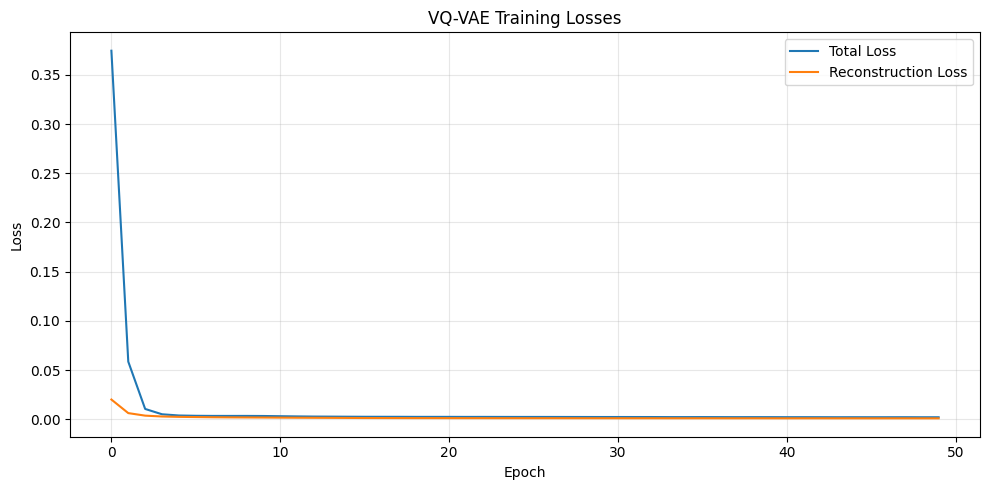

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Total Loss')
plt.plot(recon_losses, label='Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VQ-VAE Training Losses')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curve.png", dpi=150)
plt.show()

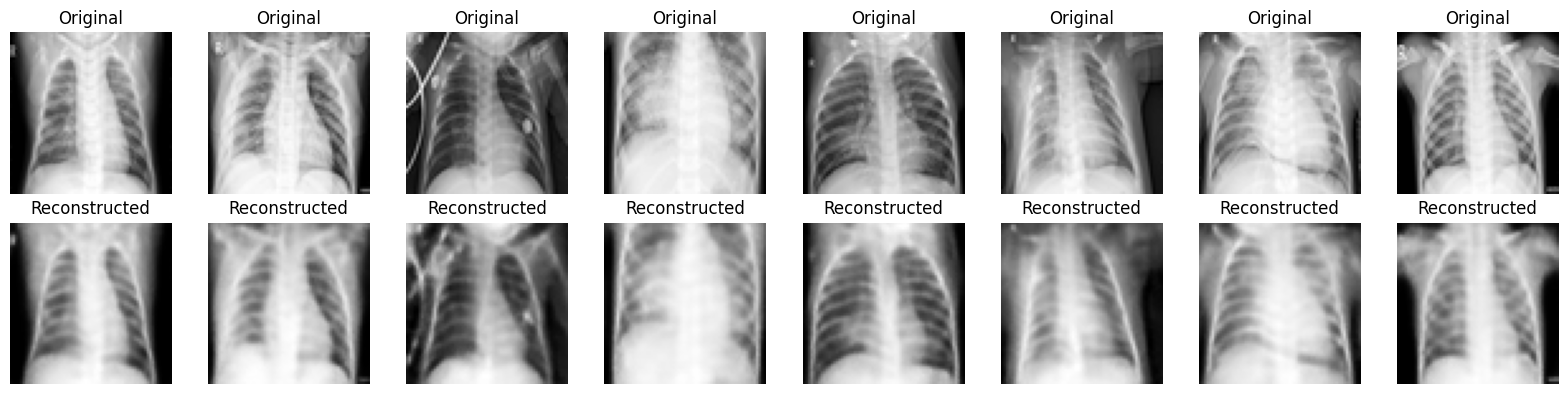

In [14]:
# visualize reconstructions
model.eval()
sample_batch = next(iter(dataloader))[:8].to(device)

with torch.no_grad():
    recon, _, _, _ = model(sample_batch)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(sample_batch[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('Original')
    axes[1, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('Reconstructed')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "reconstructions.png", dpi=150)
plt.show()

## Generate 100 Images

**Limitation:** Without a PixelCNN prior, we sample codebook indices randomly.
This breaks spatial correlations — results will be noisy/unrealistic.
Proper generation requires training an autoregressive model on the learned indices.

In [15]:
generated_dir = OUTPUT_DIR / "images"
generated_dir.mkdir(parents=True, exist_ok=True)

model.eval()
generated_paths = []

# latent spatial size: 64/4 = 16
LATENT_H, LATENT_W = 16, 16

with torch.no_grad():
    for i in tqdm(range(N_GENERATE), desc="Generating"):
        # random codebook indices
        indices = torch.randint(0, NUM_EMBEDDINGS, (LATENT_H * LATENT_W,), device=device)
        
        # lookup embeddings
        z_q = model.vq.embedding(indices)
        z_q = z_q.view(1, LATENT_H, LATENT_W, EMBED_DIM)
        z_q = z_q.permute(0, 3, 1, 2).contiguous()
        
        # decode
        fake = model.decode(z_q)
        
        img = fake.squeeze().cpu().numpy()
        img = (img * 255).astype(np.uint8)
        img = Image.fromarray(img, mode='L')
        
        out_path = generated_dir / f"{i:04d}.png"
        img.save(out_path, 'PNG')
        generated_paths.append(out_path)

print(f"Generated {len(generated_paths)} images")
print("Note: Images may look noisy due to random codebook sampling (no PixelCNN prior)")

Generating: 100%|██████████| 100/100 [00:00<00:00, 709.67it/s]

Generated 100 images
Note: Images may look noisy due to random codebook sampling (no PixelCNN prior)


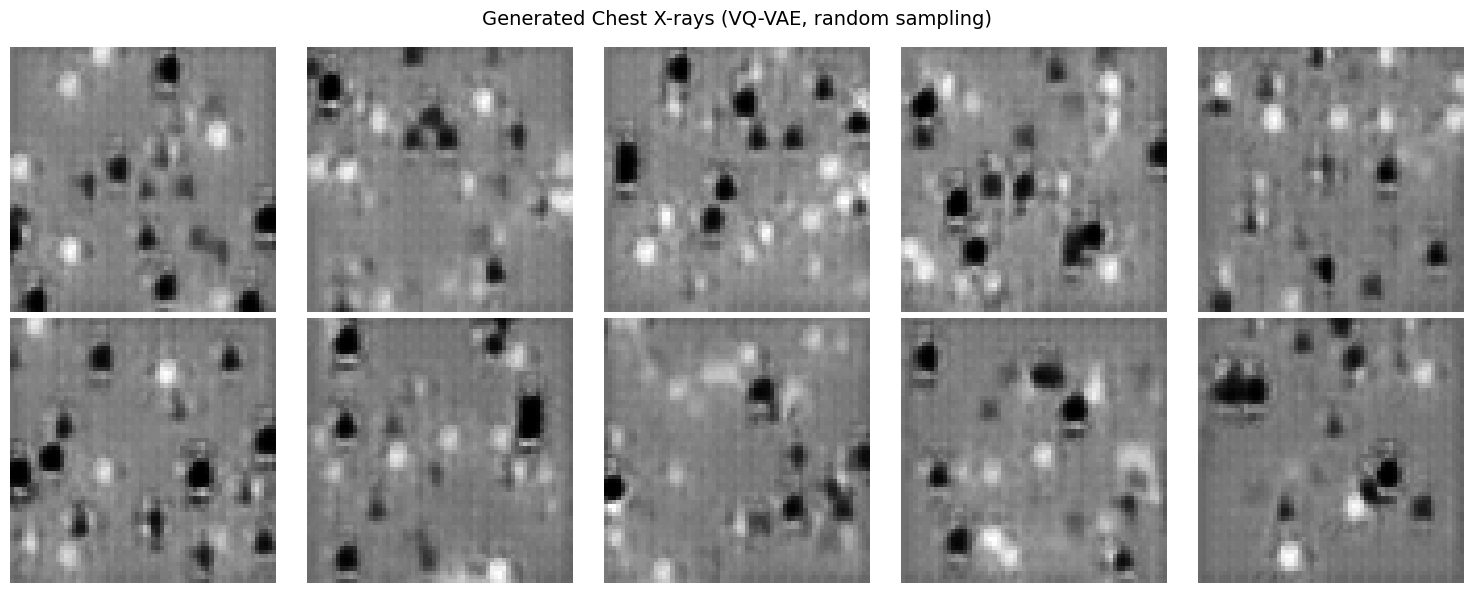

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Generated Chest X-rays (VQ-VAE, random sampling)", fontsize=14)

for ax, img_path in zip(axes.flat, generated_paths[:10]):
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "generated_samples.png", dpi=150)
plt.show()

## Evaluate — FID (domain-adapted, DenseNet121 features)

In [17]:
xrv_model = xrv.models.DenseNet(weights="densenet121-res224-all")
xrv_model = xrv_model.to(device)
xrv_model.eval()

feature_extractor = nn.Sequential(*list(xrv_model.features.children()))
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]


Sequential(
  (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, kernel_size=(1, 1), stride=(

In [18]:
def load_and_preprocess_for_xrv(img_path):
    img = Image.open(img_path).convert('L')
    img = img.resize((224, 224), Image.LANCZOS)
    img = np.array(img, dtype=np.float32)
    img = (img / 255.0) * 2048 - 1024
    img = img[np.newaxis, ...]
    return torch.tensor(img, dtype=torch.float32)


def extract_features(image_paths, batch_size=32):
    features = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Extracting features"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        with torch.no_grad():
            feat = feature_extractor(batch)
            feat = feat.mean(dim=[2, 3])
            features.append(feat.cpu().numpy())
    return np.concatenate(features, axis=0)


def compute_fid(real_features, fake_features):
    if len(real_features) < 2 or len(fake_features) < 2:
        return None
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    sigma_fake = np.cov(fake_features, rowvar=False)
    eps = 1e-6
    sigma_real += np.eye(sigma_real.shape[0]) * eps
    sigma_fake += np.eye(sigma_fake.shape[0]) * eps
    diff = mu_real - mu_fake
    try:
        covmean, _ = linalg.sqrtm(sigma_real @ sigma_fake, disp=False)
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        if not np.isfinite(covmean).all():
            return None
        fid = float(diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean))
        return fid if np.isfinite(fid) else None
    except Exception:
        return None

In [19]:
real_paths = sorted([p for p in REAL_DIR.iterdir() if p.suffix == '.png'])[:N_GENERATE]

print("Extracting features from real images...")
real_features = extract_features(real_paths)

print("Extracting features from generated images...")
fake_features = extract_features(generated_paths)

fid_score = compute_fid(real_features, fake_features)
print(f"\nDomain-adapted FID (DenseNet121): {fid_score:.2f}")
print("Note: FID may be high due to random codebook sampling")

Extracting features from real images...


Extracting features: 100%|██████████| 4/4 [00:00<00:00,  6.22it/s]


Extracting features from generated images...


Extracting features: 100%|██████████| 4/4 [00:00<00:00,  9.85it/s]



Domain-adapted FID (DenseNet121): 46.59
Note: FID may be high due to random codebook sampling


## Evaluate — Label + TSTR (torchxrayvision)

In [20]:
def label_images(image_paths, batch_size=32):
    all_predictions = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Labeling"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        with torch.no_grad():
            outputs = xrv_model(batch)
            all_predictions.append(outputs.cpu().numpy())
    return np.concatenate(all_predictions, axis=0)

In [21]:
predictions = label_images(generated_paths)
pathology_names = xrv_model.pathologies

pneumonia_idx = next(
    (i for i, name in enumerate(pathology_names) if 'lung opacity' in name.lower()),
    None
)
print(f"Using pathology index {pneumonia_idx}: {pathology_names[pneumonia_idx]}")

Labeling: 100%|██████████| 4/4 [00:00<00:00,  5.61it/s]

Using pathology index 16: Lung Opacity


In [22]:
pneumonia_scores = predictions[:, pneumonia_idx]
threshold = 0.5
positives = (pneumonia_scores > threshold).sum()
tstr_accuracy = positives / len(pneumonia_scores) * 100

print(f"\nProxy TSTR Results:")
print(f"  Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"  Classified as pneumonia (>{threshold}): {positives}/{len(pneumonia_scores)} ({tstr_accuracy:.1f}%)")


Proxy TSTR Results:
  Mean pneumonia score: 0.941
  Classified as pneumonia (>0.5): 100/100 (100.0%)


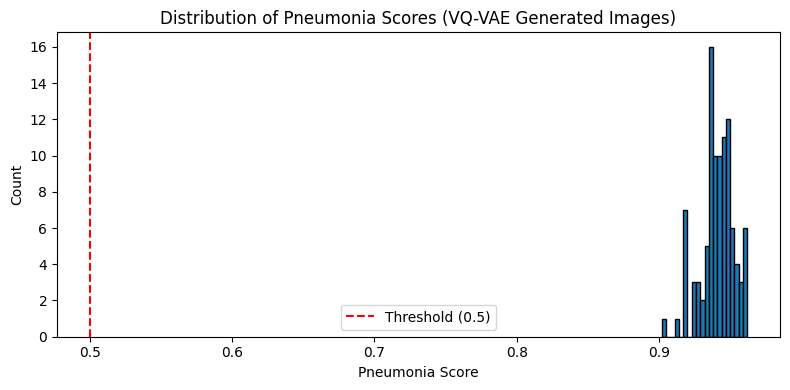

In [23]:
plt.figure(figsize=(8, 4))
plt.hist(pneumonia_scores, bins=20, edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Pneumonia Score')
plt.ylabel('Count')
plt.title('Distribution of Pneumonia Scores (VQ-VAE Generated Images)')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pneumonia_scores.png", dpi=150)
plt.show()

## Export (images/ + labels.csv + metrics.json)

In [24]:
labels_df = pd.DataFrame({
    'filename': [p.name for p in generated_paths],
    'pneumonia_score': pneumonia_scores,
    'predicted_label': ['pneumonia' if s > threshold else 'normal' for s in pneumonia_scores]
})

for i, name in enumerate(pathology_names):
    labels_df[name] = predictions[:, i]

labels_path = OUTPUT_DIR / "labels.csv"
labels_df.to_csv(labels_path, index=False)
print(f"Saved labels to {labels_path}")

Saved labels to outputs/04_vqvae/labels.csv


In [25]:
metrics = {
    'model': 'vqvae',
    'n_generated': len(generated_paths),
    'fid_domain_adapted': fid_score,
    'tstr_accuracy': tstr_accuracy,
    'mean_pneumonia_score': float(pneumonia_scores.mean()),
    'epochs': N_EPOCHS,
    'batch_size': BATCH_SIZE,
    'hidden_dim': HIDDEN_DIM,
    'embed_dim': EMBED_DIM,
    'num_embeddings': NUM_EMBEDDINGS,
    'beta': BETA,
    'learning_rate': LR,
    'final_loss': train_losses[-1] if train_losses else None,
    'final_recon_loss': recon_losses[-1] if recon_losses else None,
    'seed': SEED,
    'note': 'Random codebook sampling without PixelCNN prior'
}

metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Saved metrics to {metrics_path}")
print(json.dumps(metrics, indent=2))

Saved metrics to outputs/04_vqvae/metrics.json
{
  "model": "vqvae",
  "n_generated": 100,
  "fid_domain_adapted": 46.586989168788534,
  "tstr_accuracy": 100.0,
  "mean_pneumonia_score": 0.9408174753189087,
  "epochs": 50,
  "batch_size": 32,
  "hidden_dim": 128,
  "embed_dim": 64,
  "num_embeddings": 512,
  "beta": 0.25,
  "learning_rate": 0.001,
  "final_loss": 0.0021171183748678727,
  "final_recon_loss": 0.0010161337583164168,
  "seed": 42,
  "note": "Random codebook sampling without PixelCNN prior"
}


## Results

In [26]:
print("="*50)
print("VQ-VAE RESULTS")
print("="*50)
print(f"Images generated: {len(generated_paths)}")
print(f"Training epochs: {N_EPOCHS}")
print(f"Domain-adapted FID: {fid_score:.2f}")
print(f"Proxy TSTR accuracy: {tstr_accuracy:.1f}%")
print(f"Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"Final loss: {train_losses[-1]:.4f}")
print(f"Final recon loss: {recon_losses[-1]:.4f}")
print("="*50)
print("Note: Generation uses random codebook sampling (no PixelCNN prior)")

VQ-VAE RESULTS
Images generated: 100
Training epochs: 50
Domain-adapted FID: 46.59
Proxy TSTR accuracy: 100.0%
Mean pneumonia score: 0.941
Final loss: 0.0021
Final recon loss: 0.0010
Note: Generation uses random codebook sampling (no PixelCNN prior)
